In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv(
    "../data/processed data/clean_air_pollution.csv"
)

df.head()

,country,city,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2_5_aqi_value,pm2_5_aqi_category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [7]:
df.shape

(23462, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23462 entries, 0 to 23461
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country             23462 non-null  object
 1   city                23462 non-null  object
 2   aqi_value           23462 non-null  int64 
 3   aqi_category        23462 non-null  object
 4   co_aqi_value        23462 non-null  int64 
 5   co_aqi_category     23462 non-null  object
 6   ozone_aqi_value     23462 non-null  int64 
 7   ozone_aqi_category  23462 non-null  object
 8   no2_aqi_value       23462 non-null  int64 
 9   no2_aqi_category    23462 non-null  object
 10  pm2_5_aqi_value     23462 non-null  int64 
 11  pm2_5_aqi_category  23462 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
aqi_value,23462.0,72.011039,56.056409,6.0,39.0,55.0,79.0,500.0
co_aqi_value,23462.0,1.368383,1.832101,0.0,1.0,1.0,1.0,133.0
ozone_aqi_value,23462.0,35.193163,28.099198,0.0,21.0,31.0,40.0,235.0
no2_aqi_value,23462.0,3.063294,5.254217,0.0,0.0,1.0,4.0,91.0
pm2_5_aqi_value,23462.0,68.519777,54.797611,0.0,35.0,54.0,79.0,500.0


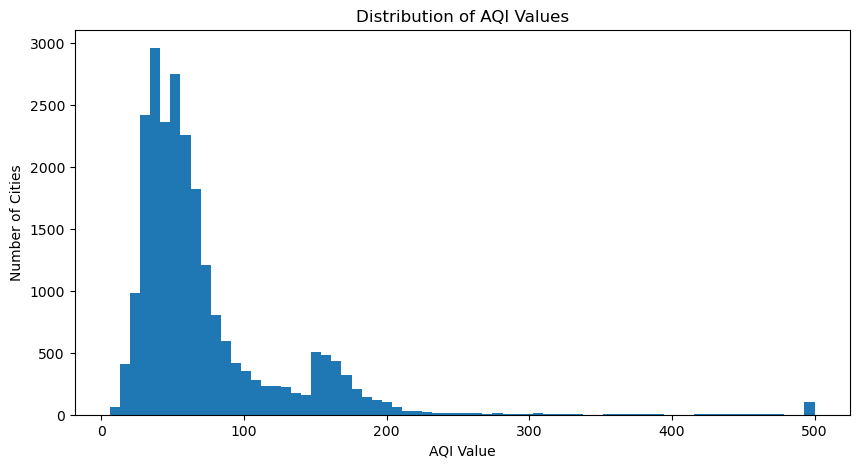

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(df["aqi_value"], bins=70)

plt.title("Distribution of AQI Values")
plt.xlabel("AQI Value")
plt.ylabel("Number of Cities")

plt.show()

In [27]:
df["aqi_category"].value_counts()

aqi_category
Good                              9936
Moderate                          9230
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

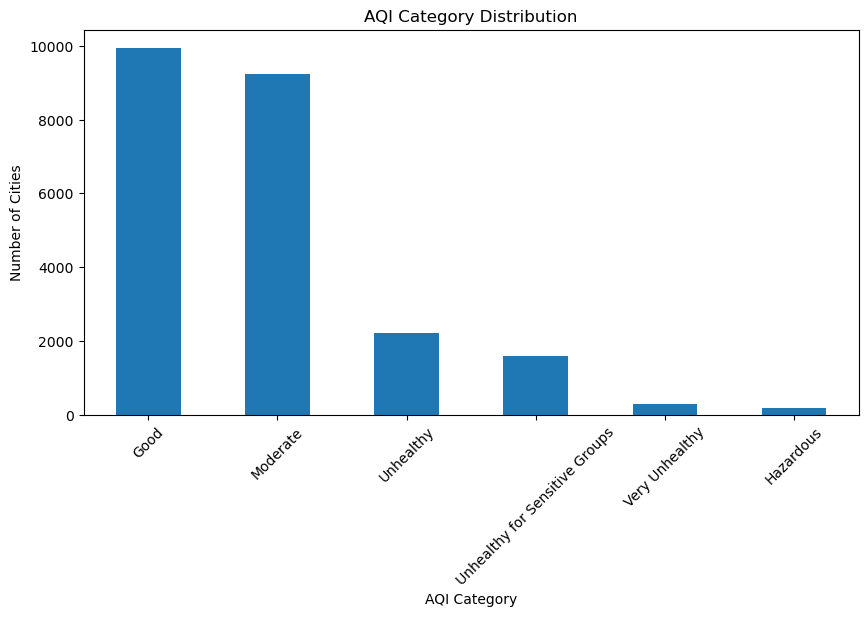

In [29]:
df["aqi_category"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Number of Cities")

plt.xticks(rotation=45)
plt.show()

In [31]:
country_aqi = (
    df.groupby("country")["aqi_value"]
    .mean()
    .sort_values(ascending=False)
)

country_aqi.head(10)

country
Republic of Korea                   421.000000
Mauritania                          179.000000
Pakistan                            178.704545
Bahrain                             173.500000
United Arab Emirates                163.666667
Aruba                               163.000000
Saint Vincent and the Grenadines    163.000000
Kuwait                              162.000000
Qatar                               157.500000
India                               152.560703
Name: aqi_value, dtype: float64

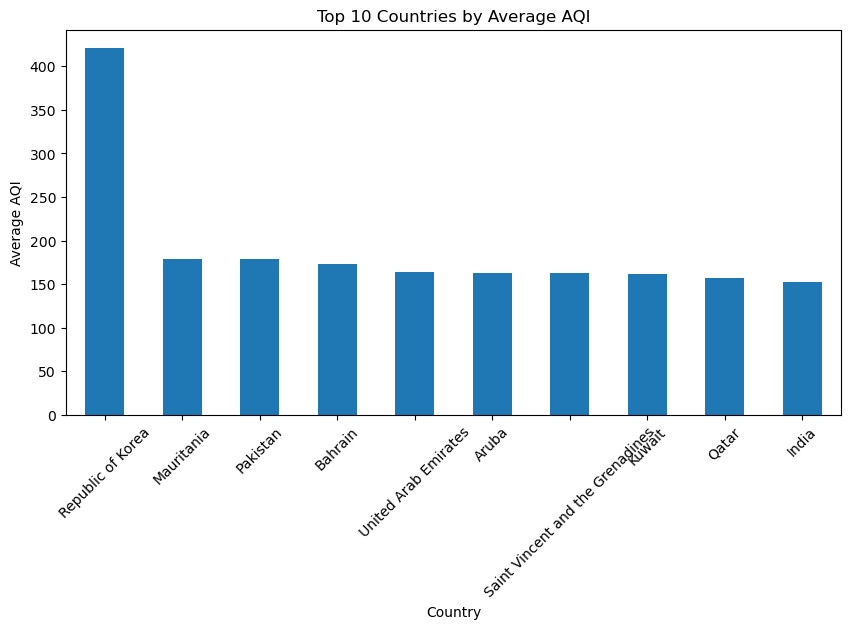

In [33]:
country_aqi.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Countries by Average AQI")
plt.xlabel("Country")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)
plt.show()

In [35]:
city_aqi = (
    df.groupby(["country", "city"])["aqi_value"]
    .mean()
    .sort_values(ascending=False)
)

city_aqi.head(20)

country   city     
India     Malaut       500.0
          Mailani      500.0
          Rania        500.0
          Rohtak       500.0
          Nawalgarh    500.0
          Julana       500.0
          Hansi        500.0
          Haldaur      500.0
          Tikri        500.0
          Khetri       500.0
          Ratangarh    500.0
          Pilibanga    500.0
          Gunnaur      500.0
          Pilani       500.0
          Dhanaura     500.0
          Gulaothi     500.0
          Pokaran      500.0
Pakistan  Harunabad    500.0
India     Ujhani       500.0
          Tajpur       500.0
Name: aqi_value, dtype: float64

In [39]:
pollutants = [
    "co_aqi_value",
    "ozone_aqi_value",
    "no2_aqi_value",
    "pm2_5_aqi_value"
]

df[pollutants].describe().T

,count,mean,std,min,25%,50%,75%,max
co_aqi_value,23462.0,1.368383,1.832101,0.0,1.0,1.0,1.0,133.0
ozone_aqi_value,23462.0,35.193163,28.099198,0.0,21.0,31.0,40.0,235.0
no2_aqi_value,23462.0,3.063294,5.254217,0.0,0.0,1.0,4.0,91.0
pm2_5_aqi_value,23462.0,68.519777,54.797611,0.0,35.0,54.0,79.0,500.0


In [41]:
df[pollutants].mean().sort_values(ascending=False)

pm2_5_aqi_value    68.519777
ozone_aqi_value    35.193163
no2_aqi_value       3.063294
co_aqi_value        1.368383
dtype: float64

In [45]:
correlation = df[
    [
        "aqi_value",
        "co_aqi_value",
        "ozone_aqi_value",
        "no2_aqi_value",
        "pm2_5_aqi_value"
    ]
].corr()

correlation

,aqi_value,co_aqi_value,ozone_aqi_value,no2_aqi_value,pm2_5_aqi_value
aqi_value,1.000000,0.430601,0.405313,0.231759,0.984327
co_aqi_value,0.430601,1.000000,0.145728,0.488094,0.438558
ozone_aqi_value,0.405313,0.145728,1.000000,-0.181822,0.339888
no2_aqi_value,0.231759,0.488094,-0.181822,1.000000,0.260127
pm2_5_aqi_value,0.984327,0.438558,0.339888,0.260127,1.000000


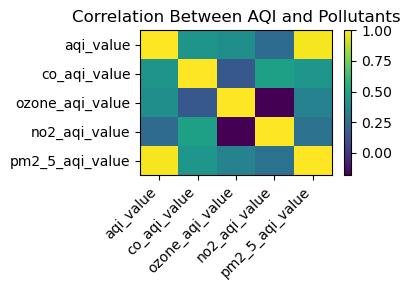

In [49]:
plt.figure(figsize=(4, 3))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between AQI and Pollutants")

plt.tight_layout()
plt.show()